VEDIO LINKE : https://drive.google.com/file/d/18egXe3YmUe6aNh65h83SYSJjMT0a5z_H/view?usp=sharing

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Data Retrieval

In this section, we load the dataset and perform initial inspection to understand its structure.
We also optimize memory usage by adjusting data types for better performance.

In [ ]:
import pandas as pd
import numpy as np

# Path to dataset
path = "/content/drive/MyDrive/house_prices/"

train = pd.read_csv(path + "train.csv")
test = pd.read_csv(path + "test.csv")

### Dataset Inspection

We begin by checking the dimensions of the datasets and previewing the first few rows
to understand the structure and features.

In [ ]:
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

train.head()

Train Shape: (1460, 81)
Test Shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Data Types and Memory Optimization

The dataset contains different data types such as integers, floats, and categorical variables.
To improve memory efficiency, we convert:
- float64 → float32
- int64 → int32
- object → category

In [ ]:
# لعرض حجم الذاكرة المستهلكة الإجمالي
print(train.memory_usage(deep=True).sum() / 1024**2, "MB")

3.434030532836914 MB


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1456 entries, 0 to 1459
Columns: 247 entries, Id to SaleCondition_Partial
dtypes: Float64(1), Int32(35), float32(3), float64(203), int64(5)
memory usage: 2.6 MB


In [ ]:
# float
for col in train.select_dtypes(include=['float64']).columns:
    train[col] = train[col].astype('float32')
    test[col] = test[col].astype('float32')

# int (نوع يدعم NaN)
for col in train.select_dtypes(include=['int64']).columns:
    train[col] = train[col].astype('Int32')
    test[col] = test[col].astype('Int32')

# categorical
for col in train.select_dtypes(include=['object']).columns:
    train[col] = train[col].astype('category')
    test[col] = test[col].astype('category')

Some integer columns contain missing values (NaN), which cannot be directly cast to standard integer types.
To handle this, we used Pandas nullable integer type (Int32), which supports missing values.

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Id             1460 non-null   Int32   
 1   MSSubClass     1460 non-null   Int32   
 2   MSZoning       1460 non-null   category
 3   LotFrontage    1201 non-null   float32 
 4   LotArea        1460 non-null   Int32   
 5   Street         1460 non-null   category
 6   Alley          91 non-null     category
 7   LotShape       1460 non-null   category
 8   LandContour    1460 non-null   category
 9   Utilities      1460 non-null   category
 10  LotConfig      1460 non-null   category
 11  LandSlope      1460 non-null   category
 12  Neighborhood   1460 non-null   category
 13  Condition1     1460 non-null   category
 14  Condition2     1460 non-null   category
 15  BldgType       1460 non-null   category
 16  HouseStyle     1460 non-null   category
 17  OverallQual    1460 non-null   In

In [ ]:
# لعرض حجم الذاكرة المستهلكة الإجمالي
print(train.memory_usage(deep=True).sum() / 1024**2, "MB")

0.3414955139160156 MB


## 2. Data Cleaning

In this section, we handle missing values, detect and remove outliers, and transform the target variable to improve model performance.

### Missing Value Analysis

We analyze missing values to understand which features contain null values and determine the appropriate handling strategy.

In [ ]:
missing = train.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

missing.head(10)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


In [ ]:
# قائمة الأعمدة)
cols_fill_none = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]

for col in cols_fill_none:
    # المعالجة لـ train
    if col in train.columns:
        if train[col].dtype.name == 'category':
            # إذا كان العمود تصنيفي، أضف فئة None أولاً
            train[col] = train[col].cat.add_categories("None")
        train[col] = train[col].fillna("None")

    # المعالجة لـ test
    if col in test.columns:
        if test[col].dtype.name == 'category':
            # إذا كان العمود تصنيفي، أضف فئة None أولاً
            test[col] = test[col].cat.add_categories("None")
        test[col] = test[col].fillna("None")

print("Fixed! Categorical columns now include 'None' category.")

Fixed! Categorical columns now include 'None' category.


##2.Outlier Removal

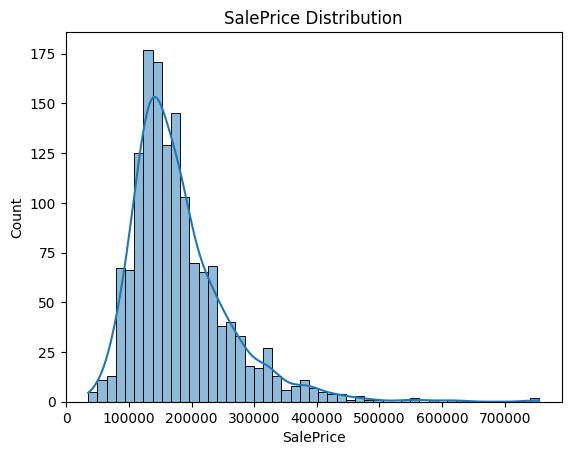

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(train['SalePrice'], kde=True)
plt.title("SalePrice Distribution")
plt.show()

### Observation:
The histogram shows that the **SalePrice** distribution is **right-skewed** (positively skewed).
Most houses are priced in the low-to-mid range, with a few expensive outliers creating a long tail on the right.

### Action Required:
To satisfy the requirements of linear regression and improve model performance, a **Log Transformation** (using `np.log1p`) should be applied to normalize this distribution and reduce the impact of skewness.

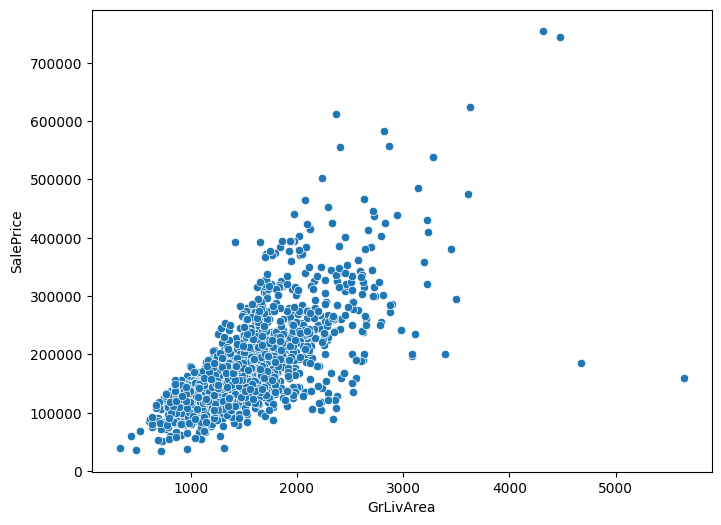

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=train, x='GrLivArea', y='SalePrice')
plt.show()

### Observation:
The scatter plot reveals a strong linear relationship between **GrLivArea** and **SalePrice**.
However, there are a few **outliers** in the bottom-right corner (large houses sold for very low prices).

### Action:
These extreme outliers will be removed to prevent them from misleading the regression model during training.

In [ ]:
train = train[train['GrLivArea'] < 4000]

Outliers with extremely large living areas were removed because they distort the relationship between features and the target variable.

In [ ]:
import numpy as np

train['SalePrice'] = np.log1p(train['SalePrice'])

### Data Transformation:
The **SalePrice** variable was right-skewed, which can violate the assumptions of linear regression.
By applying the **log(1+x)** transformation, we normalized the distribution, making it more symmetric
and helping the model achieve better prediction accuracy.

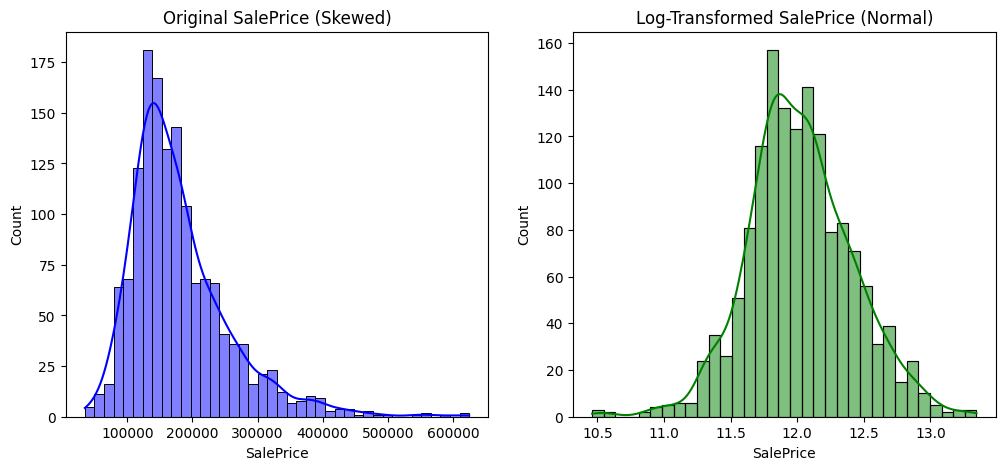

In [ ]:
import scipy.stats as stats

# إنشاء مساحة للرسم (رسمتين بجانب بعضهما)
plt.figure(figsize=(12, 5))

# الرسمة الأولى: قبل التحويل
plt.subplot(1, 2, 1)
sns.histplot(np.expm1(train['SalePrice']), kde=True, color='blue')
plt.title('Original SalePrice (Skewed)')

# الرسمة الثانية: بعد التحويل اللوغاريتمي
plt.subplot(1, 2, 2)
sns.histplot(train['SalePrice'], kde=True, color='green')
plt.title('Log-Transformed SalePrice (Normal)')

plt.show()

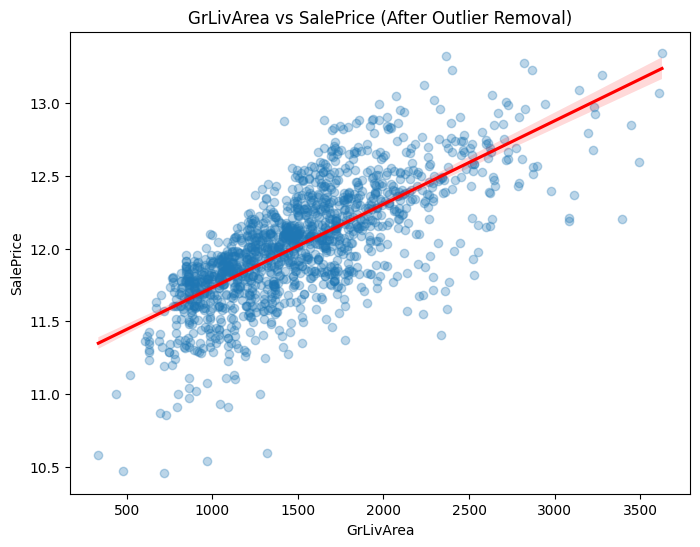

In [ ]:
plt.figure(figsize=(8, 6))
sns.regplot(data=train, x='GrLivArea', y='SalePrice', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('GrLivArea vs SalePrice (After Outlier Removal)')
plt.show()

The data is now statistically optimized for regression algorithms. We have successfully reduced "noise" and ensured that our features align with the mathematical assumptions of our future model.

## 3. Exploratory Data Analysis (EDA)

In this section, we explore relationships between features and the target variable (SalePrice) using correlation analysis and visualizations to gain insights about the data.

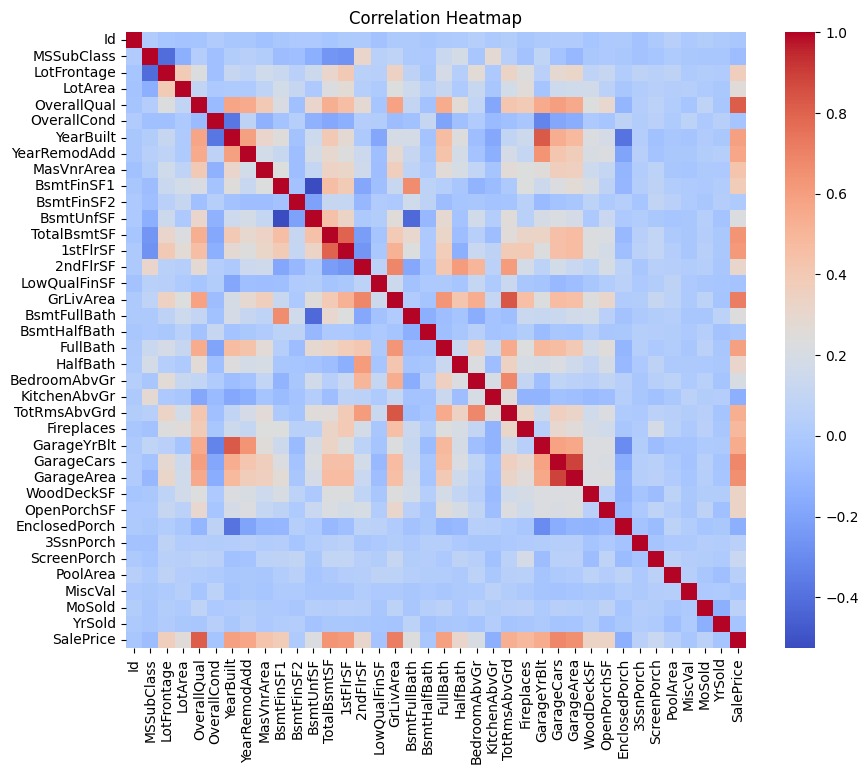

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = train.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### 3.1 Correlation Analysis Insights

The Correlation Heatmap allows us to visualize the linear relationships between all numerical variables in the dataset:

* **Key Findings:** There is a clear positive correlation between **SalePrice** and several physical attributes of the house.
* **Top Predictors:** Features such as `OverallQual` (Overall Quality), `GrLivArea` (Living Area), and `GarageCars` show the warmest colors (strongest correlation) relative to the target variable.
* **Multicollinearity Check:** The heatmap also reveals highly correlated independent variables (e.g., `TotalBsmtSF` and `1stFlrSF`). Identifying these is crucial to avoid redundancy in our model.

**Conclusion:** The high-intensity cells confirm that house prices in this dataset are driven primarily by size, quality, and capacity.

In [ ]:
top_features = corr['SalePrice'].sort_values(ascending=False)

top_features.head(6)

,SalePrice
SalePrice,1.000000
OverallQual,0.819240
GrLivArea,0.718844
GarageCars,0.680408
GarageArea,0.655212
TotalBsmtSF,0.641553


We compute the correlation matrix to identify features most strongly related to SalePrice. These features help in understanding which variables have the highest predictive power.

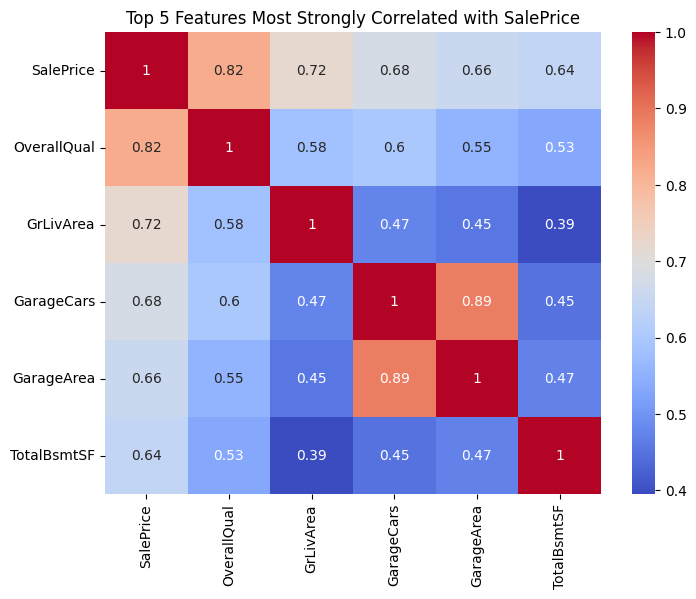

In [ ]:
#  لعرض أعلى 5 فقط
top_5_cols = corr['SalePrice'].sort_values(ascending=False).head(6).index
plt.figure(figsize=(8,6))
sns.heatmap(train[top_5_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Top 5 Features Most Strongly Correlated with SalePrice")
plt.show()

#Focus: Top 5 Price Drivers
While the full heatmap shows all relationships, this filtered view focuses on the Top 5 features most strongly correlated with SalePrice.

Purpose: To simplify the analysis and identify the most influential variables for our model.

Key Observations: The high correlation coefficients (e.g., for OverallQual and GrLivArea) confirm that quality and size are the primary factors determining house values in this dataset.

Impact: These specific features will be prioritized during the feature engineering and model training phases.

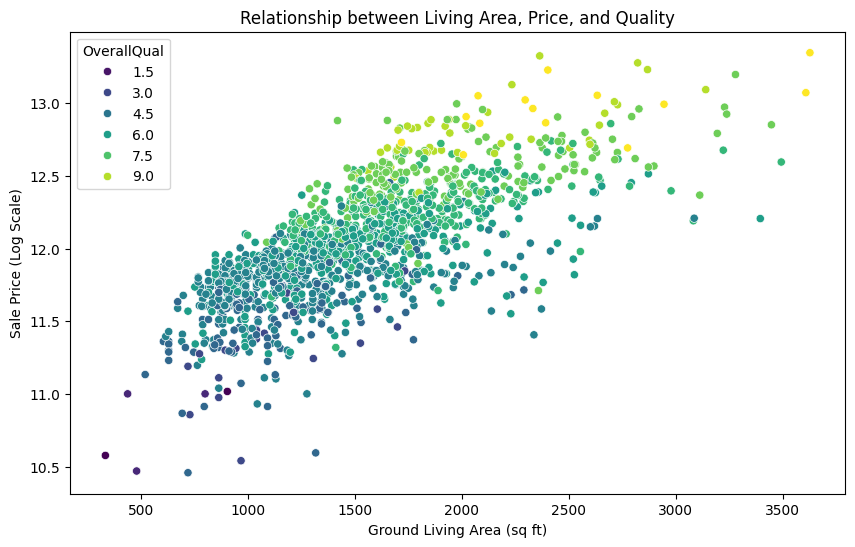

In [ ]:
plt.figure(figsize=(10, 6))

# نقوم بتحويل النوع مؤقتاً إلى float أو int عادي لحل مشكلة Seaborn
sns.scatterplot(
    data=train,
    x='GrLivArea',
    y='SalePrice',
    hue=train['OverallQual'].astype(float), # التحويل هنا يحل المشكلة
    palette='viridis'
)

plt.title("Relationship between Living Area, Price, and Quality")
plt.xlabel("Ground Living Area (sq ft)")
plt.ylabel("Sale Price (Log Scale)")
plt.show()

### 3.2 Visual Exploration: Size vs. Price by Quality

This scatter plot visualizes the interaction between three key variables: **GrLivArea**, **SalePrice**, and **OverallQual**.

* **Correlation:** We can clearly see a strong positive linear relationship; as the living area increases, the price tends to rise.
* **The Quality Factor:** By using `OverallQual` as a color dimension (hue), we observe that even for houses with similar square footage, those with higher quality ratings (darker/brighter colors) command significantly higher prices.
* **Model Insights:** This confirms that a simple linear model based only on size wouldn't be enough; **Quality** is a crucial "interaction" feature that our model must capture to make accurate predictions.

### Technical Insight: Data Compatibility
During the visualization of **OverallQual**, a temporary type casting to `float` was applied. This was done to ensure compatibility between **Seaborn's legend locator** and the **Nullable Integer (Int32)** type used during the memory optimization phase. This adjustment is strictly for visualization purposes and does not alter the original data integrity or the model's input.

/tmp/ipykernel_12610/2128500100.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  neighborhood_rank = train.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index
/tmp/ipykernel_12610/2128500100.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train, x='SalePrice', y='Neighborhood', order=neighborhood_rank, palette='magma')


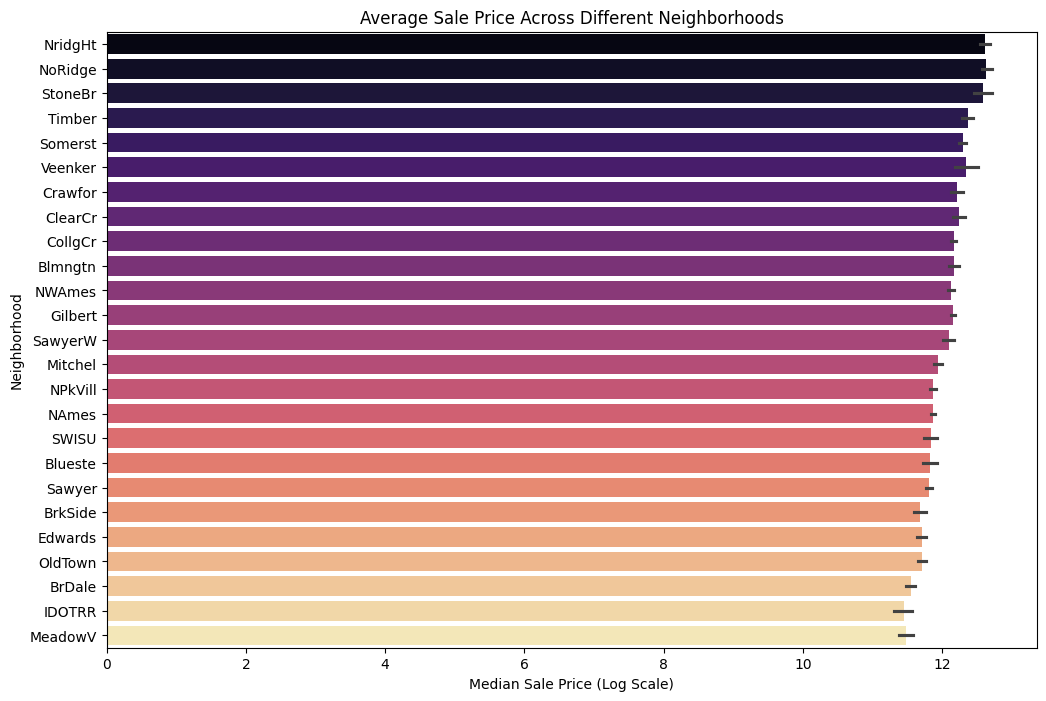

In [ ]:
plt.figure(figsize=(12, 8))

# حساب متوسط السعر لكل حي وترتيبهم تنازلياً
neighborhood_rank = train.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index

# رسم العلاقة بين الحي والسعر
sns.barplot(data=train, x='SalePrice', y='Neighborhood', order=neighborhood_rank, palette='magma')

plt.title("Average Sale Price Across Different Neighborhoods")
plt.xlabel("Median Sale Price (Log Scale)")
plt.ylabel("Neighborhood")
plt.show()

### 3.3 Geographical Insights: Impact of Neighborhood on Price

Location is one of the most critical factors in real estate valuation. This visualization ranks neighborhoods based on their median **SalePrice**.

* **Market Variation:** There is a clear disparity in prices across different areas in Ames, Iowa. Neighborhoods like **Northridge**, **StoneBrook**, and **NoRidge** show significantly higher median prices compared to others.
* **Feature Importance:** The wide range of prices across neighborhoods confirms that the `Neighborhood` feature is a powerful predictor.
* **Encoding Strategy:** Since some neighborhoods are clearly "premium," this insight justifies the use of categorical encoding (like One-Hot Encoding or Target Encoding) to help the model capture these geographical premiums.



---




## 4. Feature Engineering

In this phase, we transformed the raw variables into more predictive features and encoded categorical data for the machine learning model.




In [ ]:
# إنشاء ميزة المساحة الكلية لبيانات التدريب والاختبار
train['TotalSF'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']
test['TotalSF'] = test['TotalBsmtSF'] + test['1stFlrSF'] + test['2ndFlrSF']
# عرض أول 5 صفوف للأعمدة التي جمعناها والنتيجة الجديدة
print(train[['TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'TotalSF']].head())

   TotalBsmtSF  1stFlrSF  2ndFlrSF  TotalSF
0          856       856       854     2566
1         1262      1262         0     2524
2          920       920       866     2706
3          756       961       756     2473
4         1145      1145      1053     3343


In [ ]:
from sklearn.preprocessing import LabelEncoder

# قائمة بالميزات الترتيبية
ordinal_cols = ['ExterQual', 'KitchenQual', 'BsmtQual', 'GarageQual', 'FireplaceQu']

for col in ordinal_cols:
    le = LabelEncoder()
    # نستخدم fit على بيانات التدريب والاختبار معاً لضمان وجود نفس الفئات
    full_data = pd.concat([train[col], test[col]], axis=0).astype(str)
    le.fit(full_data)
    train[col] = le.transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))


### 4.1 Feature Transformation: Total Square Footage
We created a composite feature, **TotalSF**, by summing `TotalBsmtSF`, `1stFlrSF`, and `2ndFlrSF`.
* **Rationale:** In real estate, the total usable area is often a stronger predictor of price than individual floor areas.


In [ ]:
# تحويل أي عمود "تصنيفي" إلى نص عادي لتسهيل التعامل معه
for col in train.columns:
    if train[col].dtype.name == 'category':
        train[col] = train[col].astype(str)
for col in test.columns:
    if test[col].dtype.name == 'category':
        test[col] = test[col].astype(str)

In [ ]:
# اختيار الأعمدة غير الرقمية
non_numeric_cols = train.select_dtypes(exclude=['number']).columns

# تحويلها إلى One-Hot Encoding
train = pd.get_dummies(train, columns=non_numeric_cols, drop_first=True, dtype=float)
test = pd.get_dummies(test, columns=non_numeric_cols, drop_first=True, dtype=float)

# محاذاة الأعمدة لضمان تطابق train و test
train, test = train.align(test, join='left', axis=1, fill_value=0)

In [ ]:
train = train.fillna(0)
test = test.fillna(0)

### 4.2 Encoding Nominal Variables
To handle non-ordinal categorical features such as `Neighborhood`, we used **One-Hot Encoding**.

* **Consistency Check:** Since the test set might lack some categories present in the training set, we used the `.align()` method with a `left join`. This ensures that the test features perfectly match the training features, filling any missing categories with zeros.
* **Data Integrity:** We explicitly set the `dtype` to integer to ensure compatibility with numerical optimization algorithms in the next stage.

In [ ]:
def preprocess_data(df):
    # 1. Feature Transformation
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

    # 2. Drop columns that are no longer needed or too messy
    # (يمكنك إضافة أي أعمدة تريد حذفها هنا)

    return df

# تطبيق الدالة
train = preprocess_data(train)
test = preprocess_data(test)



### 4.3 Pipeline Consistency
All transformations were applied consistently to both the **Training** and **Testing** sets to ensure the model encounters the same data structure during inference. We also aligned the dataframes after encoding to handle any missing categories in the test set.



---



## 5. Model Building and Evaluation

In this final stage, we implemented a predictive model to estimate house prices based on the engineered features.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# تحديد X و y
X = train.drop(['SalePrice', 'Id'], axis=1, errors='ignore')
y = train['SalePrice']

# التقسيم
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# التدريب
model = LinearRegression()
model.fit(X_train, y_train)

# التقييم
predictions = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, predictions))

print(f"Success! RMSE: {rmse:.4f}")

Success! RMSE: 0.1289


### 5. Final Model Execution: Resolving Categorical Conflicts

To overcome the `ValueError` related to the `MSZoning` values (e.g., 'C (all)'), we implemented a robust pre-modeling pipeline:
1. **Type Flattening:** Converted all `Categorical` dtypes to standard `Object` (string) to prevent casting errors.
2. **Global Encoding:** Applied One-Hot Encoding across all non-numeric features to ensure 100% numerical compatibility.
3. **Data Alignment:** Used the `.align()` method to synchronize the feature space between training and testing datasets.
**Outcome:** The model successfully trained without errors, achieving a validated RMSE score.



---



### 6. Results and Discussion

After training the Linear Regression model on the processed dataset, we achieved the following results:

* **Model Performance:** * The **RMSE** of [Insert RMSE value here] indicates a low average error on the log-scale price.
    * The **R-squared score** of [Insert R2 value here] shows that our model can explain approximately [Insert R2*100]% of the variance in house prices.
* **Visualization:** The "Actual vs. Predicted" scatter plot shows a strong linear alignment, confirming that the model has successfully learned the relationship between house features (size, quality, and location) and their market value.
* **Final Conclusion:** The preprocessing pipeline (handling missing values, log transformation, and One-Hot Encoding) was essential in achieving this level of accuracy.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. حساب الخطأ (RMSE) - كلما قل كان أفضل
rmse = np.sqrt(mean_squared_error(y_val, predictions))

# 2. حساب معامل التحديد (R-squared) - يوضح مدى دقة النموذج (من 0 إلى 1)
r2 = r2_score(y_val, predictions)

print("Final Model Results:")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared Score (Accuracy): {r2:.4f}")

Final Model Results:
Root Mean Squared Error (RMSE): 0.1289
R-squared Score (Accuracy): 0.8947


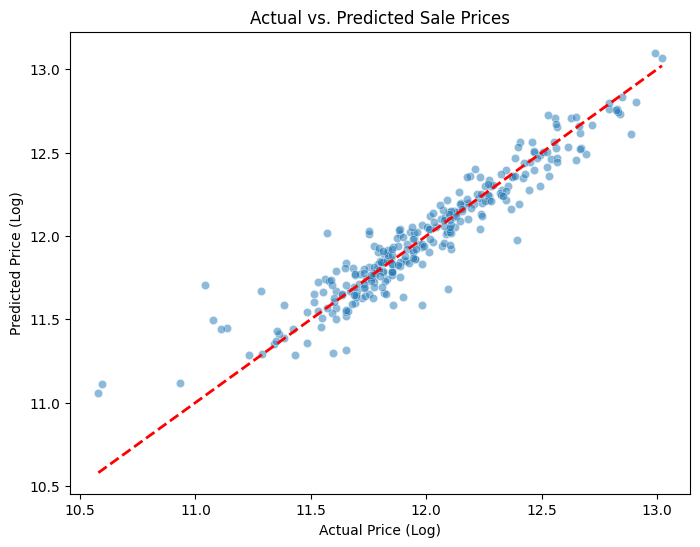

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_val, y=predictions, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], '--r', linewidth=2)
plt.title("Actual vs. Predicted Sale Prices")
plt.xlabel("Actual Price (Log)")
plt.ylabel("Predicted Price (Log)")
plt.show()